# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 50     |  |
| :-------------|:-------------|
| Rune Veraart| 6439748 |
| Pieter Broerse | 6507840 |
| Frederik Roerink | 6550223|

| Planning Groep: 50     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12:30 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:00 |
| Pauze 1| |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Foto van alle schetsen.

<p> Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto. <p>


![Alt](Ontwerpen1.jpeg "1")
![Alt](Ontwerpen1-Piet.jpg "2")
![Alt](Ontwerpen1-Fred.jpg "3")



## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Laptop homebutton | Een homebutton voor een laptop waardoor de laptop gemakkelijk aan en uit kan | Moet kunnen reageren op een druk van tussen de 0.3 kg en 0.7 kg met een onzekerheid van 0.1 kg |
| Magnetische lichtswitch | Met behulp van een magneet het licht aandoen | tussen de 0 en 2 cm met een onzekerheid van 0,3cm een magneet kunnen detecteren van tussen de 5 en 30 met een onzekerheid van 5 millitesla  |
| Laptop oververhittingssensor | Met behulp van de temperatuursensor de temperatuur van een laptop te bepalen om zo de laptop af te sluiten als deze te warm wordt | Tussen de 80 graden en de 100 graden de temperatuur op de graden nauwkeurig te meten |


Groep 50 heeft gekozen voor sensor Laptop homebutton. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
<p>Licht kort toe wat er in de foto te zien is. <p>

![Alt](Meetopstelling.jpg "6")



Op deze foto zie je alle dingen die gebruikt zijn. Het process was vrij eenvoudig. De beker werd met steentjes gevult en op de druksensor gezet. Daar werd de arduino waarde van genoteerd en vervolgens werd die zelfde beker gewogen op een weegschaal. Het gewicht en de arduino waarde waren samen genoteerd

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen?
Massa van voorwerp op de krachtsensor / netto kracht op de krachtsensor
2. Over welk bereik ga je deze variabelen veranderen?
30 gram - 4 kg
3. Wat ga je allemaal meten?
Bij verschillende massa's meten we de ADC-waarde van de Arduino.
4. Hoeveel metingen ga je doen?
10-15
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Om te evalueren of de sensor geschikt is om als home-button te fungeren, moeten er aan twee condities voldaan worden. Ten eerste moet bij het gewicht dat vergelijkbaar is met de kracht die een vinger normaal gesproken uitvoert bij het drukken op de home-button, een ADC-waarde gegeven worden die tussen de minimale waarde van 0 en maximale waarde van 1023 ligt. Als de waarde hiertussen ligt, het liefst zo veel mogelijk in het midden, kan er een bepaalde drempelwaarde worden ingesteld worden voor de ADC-waarde waarbij de knop wordt "ingedrukt". Onder deze drempelwaarde zou de vinger dan te weinig kracht hebben geleverd om de home-button te activeren. Dit is wenselijk omdat de gebruiker niet bij een incidentele aanraking met de home-button niet meteen deze wil activeren. Pas bij het echt indrukken, en dus bij een bepaalde kracht, wordt de home-button geactiveerd.
Ten tweede moet de sensor bij een massa van 5 kg nog steeds een ADC-waarde geven. Als bij een bepaalde massa in ons interval de sensor niet meer functioneert, kan een te harde druk op de home-button dus resulteren in het bezwijken van de sensor. In dit geval is de sensor niet geschikt als home-button.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
<p> Licht kort toe wat er in de foto te zien is. <p>

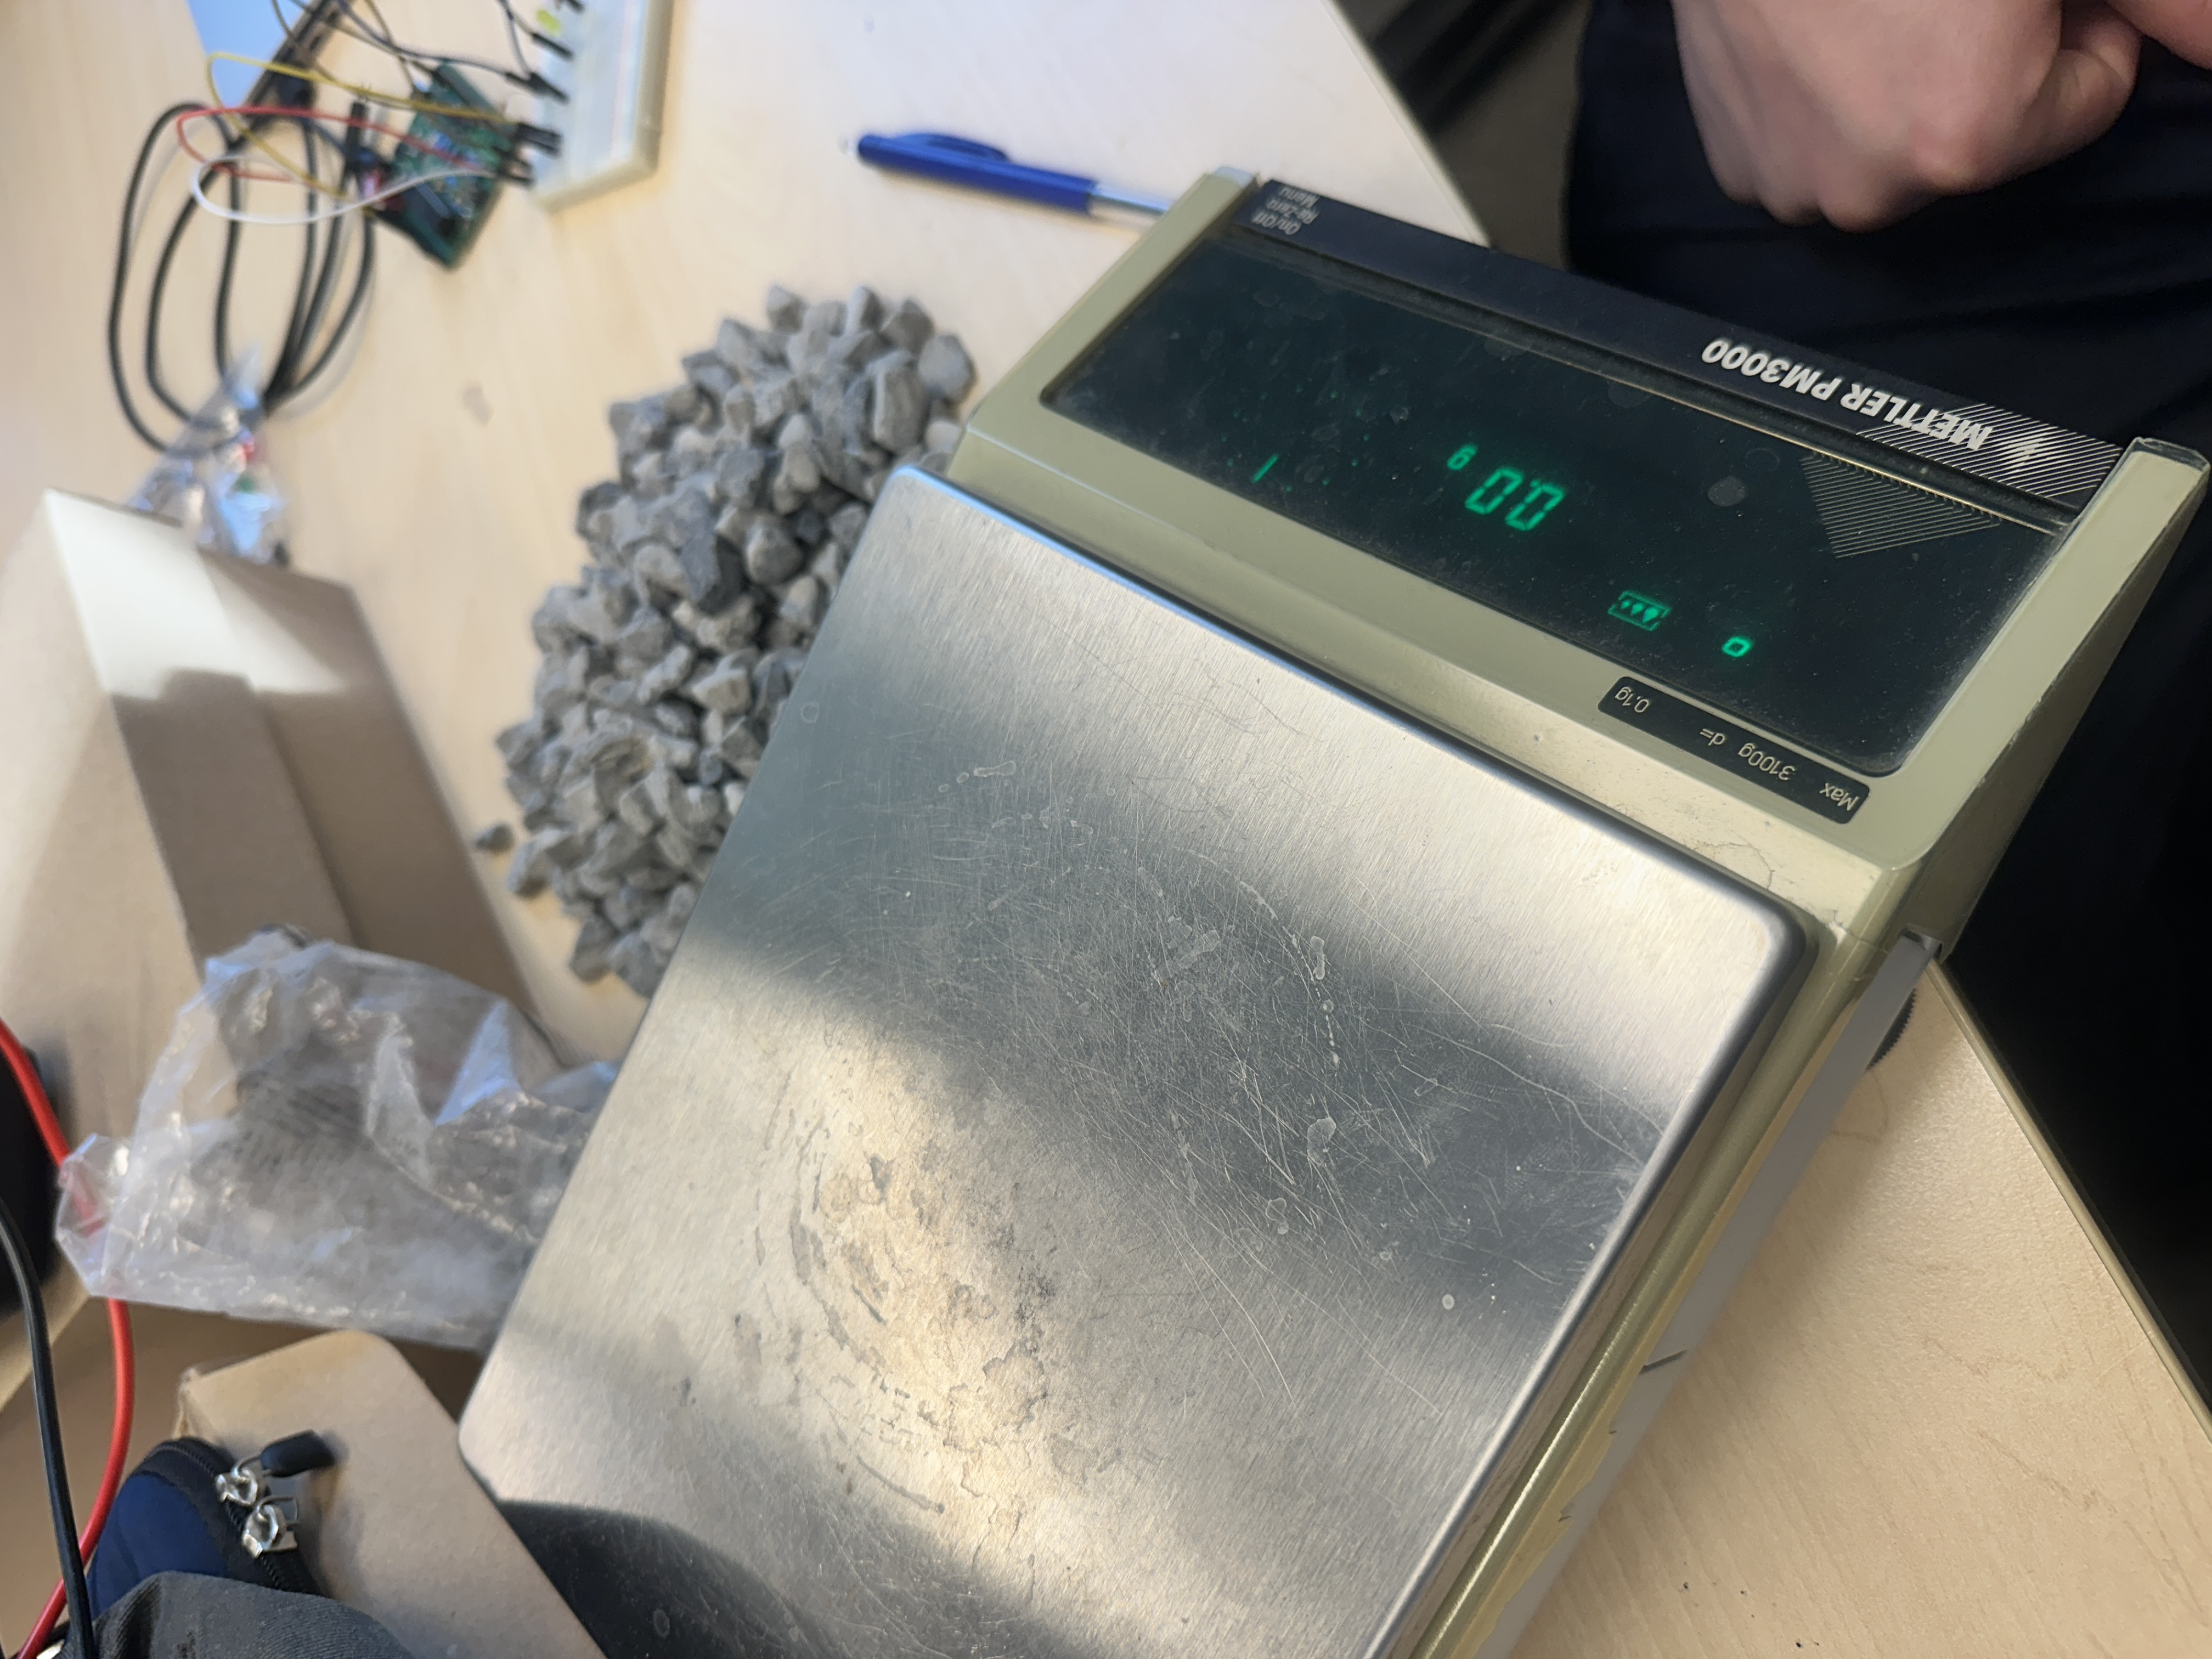

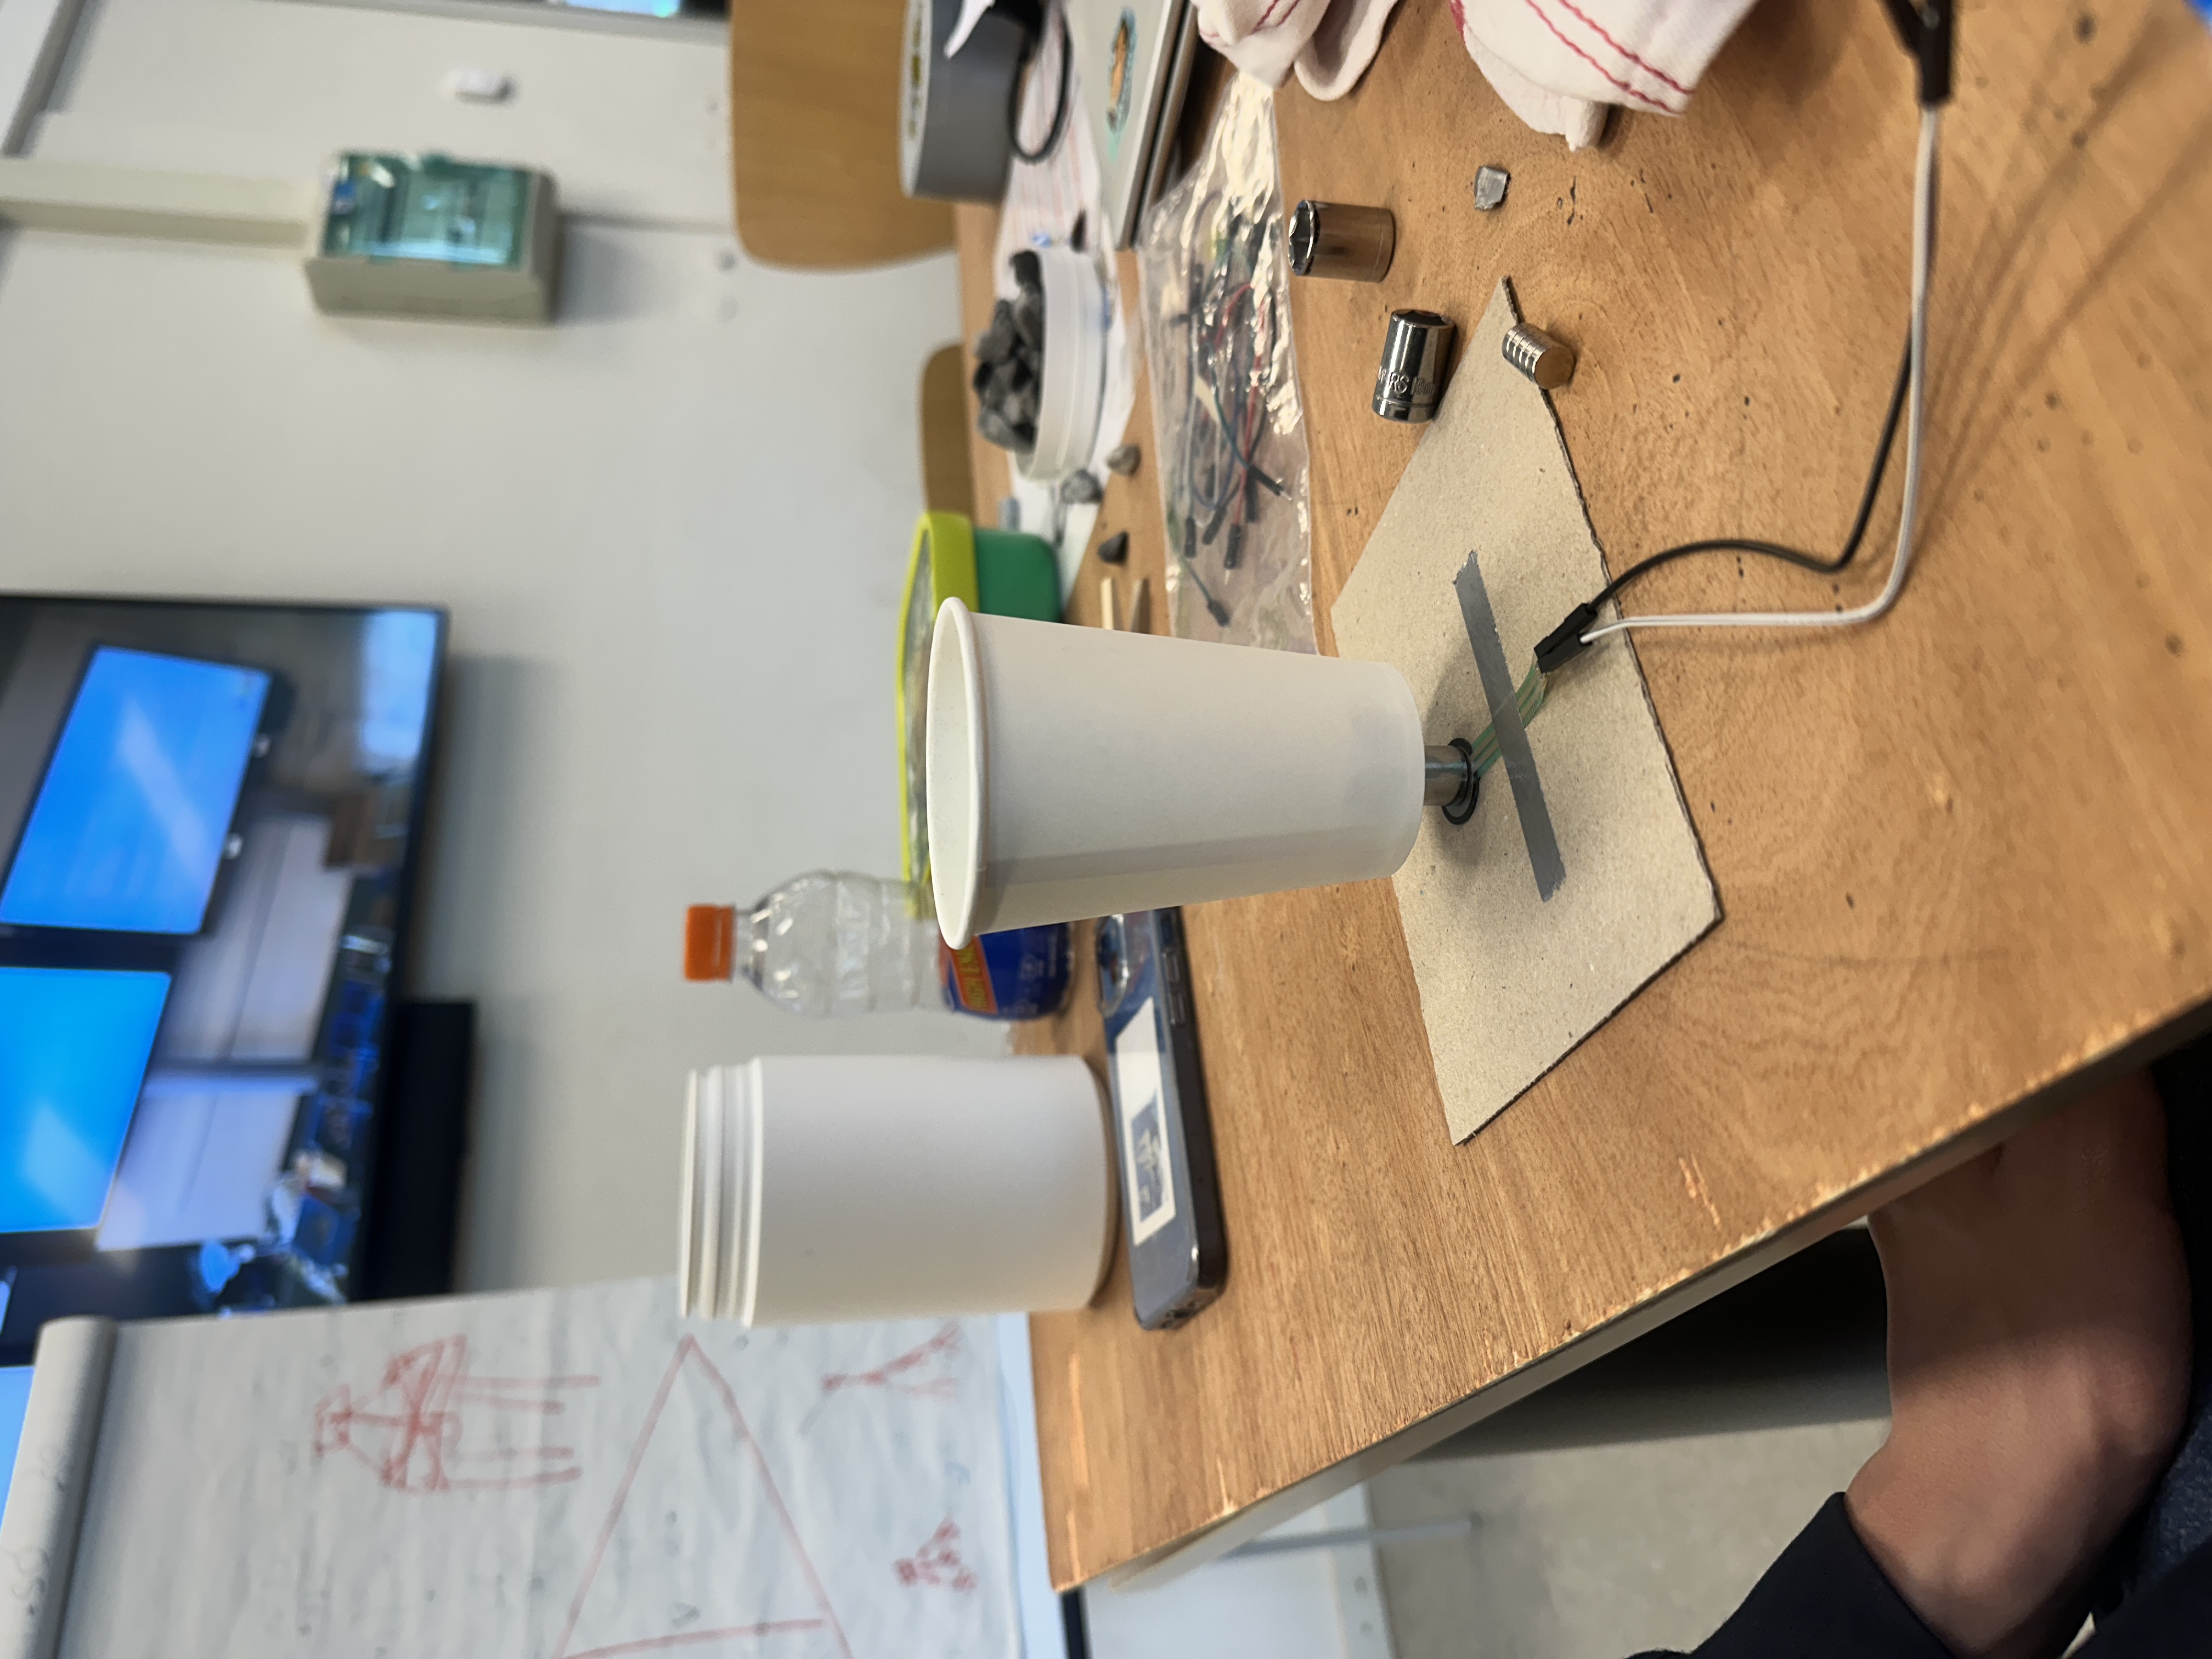

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

arduino = np.array([770,790,860,1009,1000,995,990,940,915,610,500,200,150])
u_arduino = 20
gewicht = np.array([179.4,218.6, 268.3, 803.1, 763.4, 685.2, 622.5, 444.4, 334.8, 113.8, 89.8, 43.4, 32.7])
u_gewicht = 1

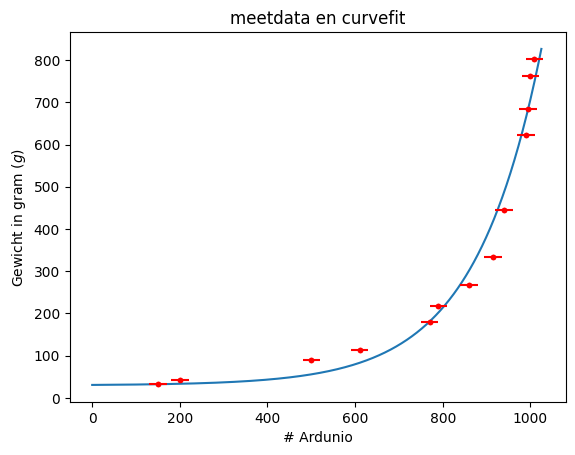

a = 29.874410033109395 +/- 18.039258136643404
b = 1.0065386304716952 +/- 4.412719897454729e-05


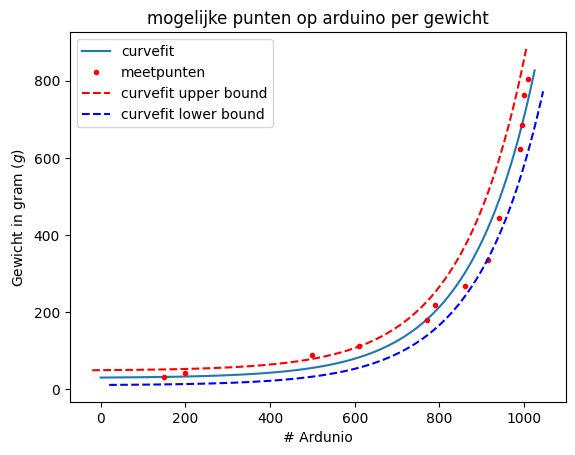

op arduino nummer 1023 is ligt het gewicht tussen de 871.2037363984084 en de 762.5788697506204 dit is een grotere onzekerheid dan 100 gram


In [2]:
def gewichten(arduino,a,b):
    return a+b**arduino
punten = np.linspace(0,1025,1000)
punt,onz = curve_fit(gewichten,arduino,gewicht)
plt.title("meetdata en curvefit")
plt.plot(arduino,gewicht,'r.')
plt.plot(punten, gewichten(punten,punt[0],punt[1]))
plt.errorbar(arduino,gewicht,u_gewicht,u_arduino,"r.")
plt.xlabel("# Ardunio")
plt.ylabel("Gewicht in gram ($g$)")
plt.show()

u_a = np.sqrt(onz[0,0])
u_b = np.sqrt(onz[1,1])

print("a =", punt[0], "+/-", u_a)
print("b =", punt[1], "+/-", u_b)
plt.title("mogelijke punten op arduino per gewicht")
plt.plot(punten, gewichten(punten,punt[0],punt[1]),label = "curvefit")
plt.plot(arduino,gewicht,'r.',label="meetpunten")
plt.plot(punten-u_arduino,gewichten(punten,punt[0]+u_a,punt[1]+u_b)+u_gewicht,"r--",label="curvefit upper bound")
plt.plot(punten+u_arduino,gewichten(punten,punt[0]-u_a,punt[1]-u_b)-u_gewicht,"b--",label="curvefit lower bound")
plt.xlabel("# Ardunio")
plt.ylabel("Gewicht in gram ($g$)")
plt.legend()
plt.show()
print("op arduino nummer 1023 is ligt het gewicht tussen de",gewichten(1023,punt[0]+u_a,punt[1]+u_b)+u_gewicht, "en de", gewichten(1023,punt[0]-u_a,punt[1]-u_b)-u_gewicht,"dit is een grotere onzekerheid dan 100 gram")

## *Opdracht 7*: Iteratie nodig?

Iteratie is in dit geval niet nodig. Met onze metingen is voldoende aangetoond dat de sensor niet als home-button kan fungeren. Om de nauwkeurigheid van het onderzoek te verbeteren kan de gewichtsverdeling van een vinger beter nagebootst worden. Wij hebben gebruik gemaakt van een kleine houder die de massa van de beker gelijkmatig over het oppervlak van de sensor verdeelde. Echt wordt de kracht van het werkelijk drukken met een vinger op een echte home-button niet gelijkmatig verdeeld over het oppervlak. Hierdoor kan het gebruik maken van gewichten op de sensor niet perfect de druk van een vinger nabootsen.

## *Opdracht 8*: Conclusie, leerdoel

Uit de uitgevoerde metingen blijkt dat de druksensor niet voldoet aan de gestelde functionele eisen. De waardes van ons gewicht konden wel worden gemeten door de arduino maar de onzekerheid bleef niet binnen de gestelde 100 gram

Daarnaast is vastgesteld dat de sensor wel voldoet aan de tweede conditie. Bij een aangelegde massa van 5 kg bleef de gemeten waarde op het maximale niveau, hetgeen duidt op verzadiging van het meetsignaal. Hoewel deze verzadiging reeds optreedt bij een belasting van circa 800 gram, vormt dit geen beperking voor de beoogde toepassing, aangezien de functionaliteit van de homebutton uitsluitend vereist dat een drukgebeurtenis wordt gedetecteerd, en niet de exacte kracht waarmee deze wordt uitgeoefend.

Op basis van deze bevindingen kan worden geconcludeerd dat de druksensor geschikt is voor toepassing als homebutton binnen het voorgestelde systeem.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.\


![Alt](IMG_1392.JPG "4")

![Alt](IMG_1393.JPG "5")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Laptop homebutton | Een homebutton voor een laptop waardoor de laptop gemakkelijk aan en uit kan | Moet kunnen reageren op een druk van tussen de 0.3 kg en 0.7 kg met een onzekerheid van 0.1 kg |
| Magnetische lichtswitch | Met behulp van een magneet het licht aandoen | tussen de 0 en 2 cm met een onzekerheid van 0,3cm een magneet kunnen detecteren van tussen de 5 en 30 met een onzekerheid van 5 millitesla  |
| Laptop oververhittingssensor | Met behulp van de temperatuursensor de temperatuur van een laptop te bepalen om zo de laptop af te sluiten als deze te warm wordt | Tussen de 80 graden en de 100 graden de temperatuur op de graden nauwkeurig te meten |


Groep 50 heeft gekozen voor sensor Laptop homebutton. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.


![Alt](IMG_1392.JPG "4")

![Alt](IMG_1393.JPG "5")

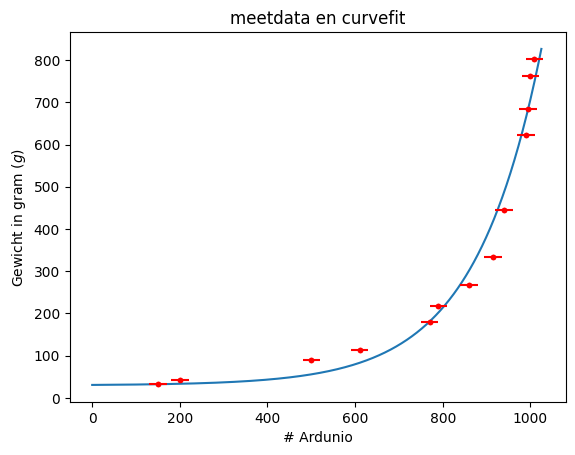

a = 29.874410033109395 +/- 18.039258136643404
b = 1.0065386304716952 +/- 4.412719897454729e-05


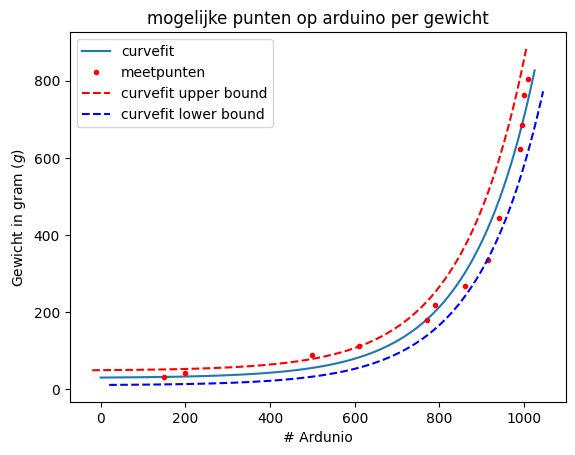

In [3]:
def gewichten(arduino,a,b):
    return a+b**arduino
punten = np.linspace(0,1025,1000)
punt,onz = curve_fit(gewichten,arduino,gewicht)
plt.title("meetdata en curvefit")
plt.plot(arduino,gewicht,'r.')
plt.plot(punten, gewichten(punten,punt[0],punt[1]))
plt.errorbar(arduino,gewicht,u_gewicht,u_arduino,"r.")
plt.xlabel("# Ardunio")
plt.ylabel("Gewicht in gram ($g$)")
plt.show()

u_a = np.sqrt(onz[0,0])
u_b = np.sqrt(onz[1,1])

print("a =", punt[0], "+/-", u_a)
print("b =", punt[1], "+/-", u_b)
plt.title("mogelijke punten op arduino per gewicht")
plt.plot(punten, gewichten(punten,punt[0],punt[1]),label = "curvefit")
plt.plot(arduino,gewicht,'r.',label="meetpunten")
plt.plot(punten-u_arduino,gewichten(punten,punt[0]+u_a,punt[1]+u_b)+u_gewicht,"r--",label="curvefit upper bound")
plt.plot(punten+u_arduino,gewichten(punten,punt[0]-u_a,punt[1]-u_b)-u_gewicht,"b--",label="curvefit lower bound")
plt.xlabel("# Ardunio")
plt.ylabel("Gewicht in gram ($g$)")
plt.legend()
plt.show()


Uit de uitgevoerde metingen blijkt dat de druksensor niet voldoet aan de gestelde functionele eisen. De waardes van ons gewicht konden wel worden gemeten door de arduino maar de onzekerheid bleef niet binnen de gestelde 100 gram

Daarnaast is vastgesteld dat de sensor wel voldoet aan de tweede conditie. Bij een aangelegde massa van 5 kg bleef de gemeten waarde op het maximale niveau, hetgeen duidt op verzadiging van het meetsignaal. Hoewel deze verzadiging reeds optreedt bij een belasting van circa 800 gram, vormt dit geen beperking voor de beoogde toepassing, aangezien de functionaliteit van de homebutton uitsluitend vereist dat een drukgebeurtenis wordt gedetecteerd, en niet de exacte kracht waarmee deze wordt uitgeoefend.

Op basis van deze bevindingen kan worden geconcludeerd dat de druksensor geschikt is voor toepassing als homebutton binnen het voorgestelde systeem.